In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import re
from tqdm import tqdm
import imageio
import os
import warnings

In [5]:
print("Wczytywanie danych...")
path = r"C:\Users\kacpe\python-Kacpeee\Andarktyda\daily_ice_edge.csv"
df = pd.read_csv(path)

print("Dane wczytane:", df.shape)

Wczytywanie danych...
Dane wczytane: (9530, 362)


In [15]:
def process_data(df):
    """
    Pipeline transformacji danych: konwersja formatu szerokiego na długi, 
    ekstrakcja cech czasowych i inżynieria współrzędnych kątowych.
    """
    print("Rozpoczynam przetwarzanie danych...")

    # Selekcja kolumn zawierających dane o zasięgu lodu (longitudes)
    long_cols = [c for c in df.columns if 'longitude_' in c]

    # Normalizacja bazy: przejście z formatu wide do long (Tidy Data)
    # Kluczowe dla efektywnej pracy z modelami regresyjnymi sklearn
    df_long = pd.melt(
        df,
        id_vars=['Date'],
        value_vars=long_cols,
        var_name='angle',
        value_name='latitude'
    )

    # Casting typu danych dla osi czasu i ustawienie formatowania europejskiego
    df_long['Date'] = pd.to_datetime(df_long['Date'], dayfirst=True)

    # Inżynieria cech (Feature Engineering): 
    # 1. day_index: trend liniowy/długoterminowy
    # 2. day_of_year: cykliczność roczna (sezonowość)
    df_long['day_index'] = (df_long['Date'] - df_long['Date'].min()).dt.days
    df_long['day_of_year'] = df_long['Date'].dt.dayofyear

    # Parser regex do ekstrakcji wartości numerycznej kąta i mapowania kierunków (E/W)
    # na wartości ujemne/dodatnie w układzie współrzędnych
    def parse_angle(text):
        num = int(re.findall(r'\d+', text)[0])
        return -num if 'W' in text else num

    # Mapowanie funkcji na zbiorze danych z wizualizacją postępu (tqdm)
    tqdm.pandas(desc="Przetwarzanie kątów")
    df_long['angle_num'] = df_long['angle'].progress_apply(parse_angle)

    # Data Cleaning: usunięcie braków danych w zmiennej objaśnianej (target)
    df_long = df_long.dropna(subset=['latitude'])

    print(f"Przetwarzanie zakończone. Wynikowy kształt: {df_long.shape}")

    return df_long

# Inicjalizacja pipeline'u
df_processed = process_data(df)

Rozpoczynam przetwarzanie danych...


Przetwarzanie kątów: 100%|███████████████████████████████████████████████| 3440330/3440330 [00:07<00:00, 441736.90it/s]

Przetwarzanie zakończone. Wynikowy kształt: (3440330, 6)


In [8]:
# Agregacja ekstremów - tworzenie geometrycznego punktu odniesienia (baseline)
min_ice = df_processed.groupby('angle_num')['latitude'].min().reset_index()

# Skalowanie szerokości geograficznej na dystans od bieguna (111.2 km/deg)
min_ice['r'] = (90 + min_ice['latitude']) * 111.2

# Normalizacja kątów do formatu matematycznego (radianty, offset -90° dla orientacji północnej)
min_ice['theta'] = np.radians(
    np.where(min_ice['angle_num'] < 0,
             360 + min_ice['angle_num'] - 90,
             min_ice['angle_num'] - 90)
)

# Transformacja współrzędnych biegunowych na kartezjańskie (XY) do wizualizacji mapy
min_ice['x'] = min_ice['r'] * np.cos(min_ice['theta'])
min_ice['y'] = min_ice['r'] * np.sin(min_ice['theta'])

Tworzenie wykresu...
Brak pliku tła


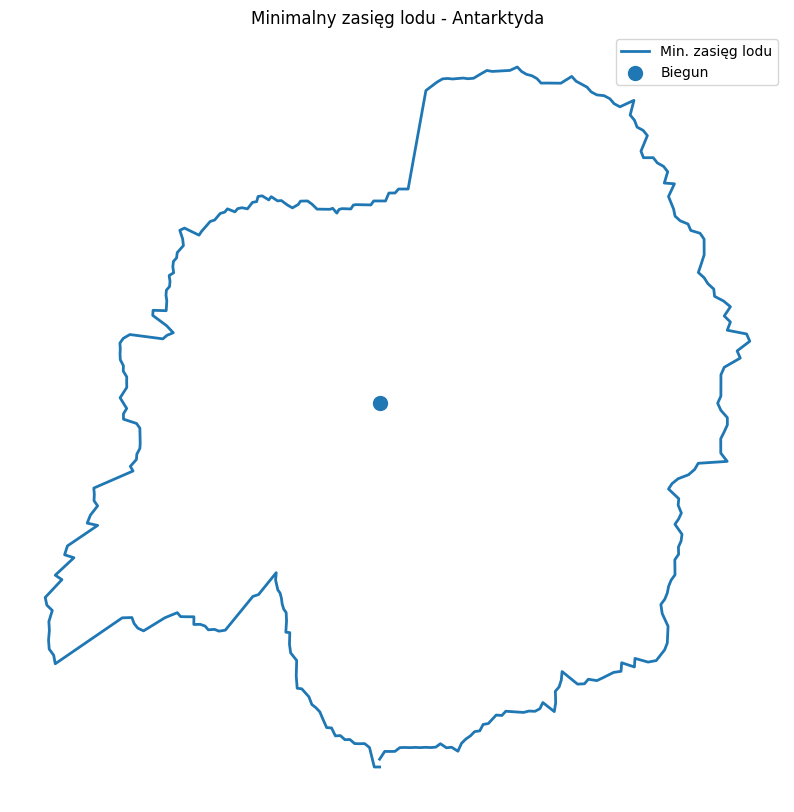

In [14]:
def plot_ice_edge(df_processed):
    """Renderowanie mapy minimalnego zasięgu lodu na podkładzie kartograficznym."""
    print("Tworzenie wykresu...")

    # Generowanie bazy (baseline) dla minimalnego zasięgu
    min_ice = df_processed.groupby('angle_num')['latitude'].min().reset_index()

    # Parametryzacja układu współrzędnych (skalowanie i orientacja kątowa)
    min_ice['r'] = (90 + min_ice['latitude']) * 111.2
    min_ice['theta'] = np.radians(
        np.where(min_ice['angle_num'] < 0,
                 360 + min_ice['angle_num'] - 90,
                 min_ice['angle_num'] - 90)
    )

    # Transformacja do układu kartezjańskiego (XY)
    min_ice['x'] = min_ice['r'] * np.cos(min_ice['theta'])
    min_ice['y'] = min_ice['r'] * np.sin(min_ice['theta'])

    plt.figure(figsize=(10, 10))

    # Import podkładu graficznego z obsługą błędów (Exception Handling)
    # Extent dopasowuje fizyczną skalę obrazu (km) do obliczonych współrzędnych XY
    try:
        img_path = r"C:\Users\kacpe\Desktop\Prace w R\Projekt_przetwarzanie\Modelowanie_projekt\antarctica.png"
        img = plt.imread(img_path)
        plt.imshow(img, extent=[-3000, 3000, -3000, 3000])
    except Exception:
        print("Brak")

    # Nakładanie warstw: krawędź lodu (plot) oraz punkt centralny bieguna (scatter)
    plt.plot(min_ice['x'], min_ice['y'], linewidth=2, label='Min. zasięg lodu')
    plt.scatter(0, 0, s=100, label='Biegun')

    plt.title("Minimalny zasięg lodu - Antarktyda")
    plt.legend()
    plt.axis('off') # Usunięcie osi dla czystego efektu mapy
    plt.show()

In [33]:


print("Inicjalizacja")

frames = []
dates = sorted(df_processed['Date'].unique())

# Downsampling danych (interwał 10-dniowy) w celu optymalizacji wydajności i rozmiaru pliku
dates = dates[::10]

temp_dir = "frames_ice"
os.makedirs(temp_dir, exist_ok=True)

# Pętla generująca klatki (frames) animacji
for i, date in enumerate(tqdm(dates, desc="Renderowanie historii")):
    # Ekstrakcja stanu lodu dla konkretnego punktu w czasie
    subset = df_processed[df_processed['Date'] == date].copy()

    if subset.empty:
        continue

    # Sortowanie kątowe zapewnia ciągłość rysowanej linii (geometryczna spójność obrysu)
    subset = subset.sort_values('angle_num')

    # Transformacja współrzędnych do układu kartezjańskiego (XY)
    # Skalowanie oparte na założeniu stałej długości stopnia (111.2 km)
    subset['r'] = (90 + subset['latitude']) * 111.2
    subset['theta'] = np.radians(
        np.where(subset['angle_num'] < 0,
                 360 + subset['angle_num'] - 90,
                 subset['angle_num'] - 90)
    )
    subset['x'] = subset['r'] * np.cos(subset['theta'])
    subset['y'] = subset['r'] * np.sin(subset['theta'])

    # Inicjalizacja figury z zachowaniem proporcji i miejsca na legendę
    fig, ax = plt.subplots(figsize=(8, 9))
    
    # 1. Warstwa bazowa (Historyczne minimum)
    ax.plot(min_ice['x'], min_ice['y'], color='gray', linestyle='--', linewidth=1, label='Min ice (Reference)', alpha=0.6)
    
    # 2. Warstwa danych bieżących (Current ice)
    ax.plot(subset['x'], subset['y'], color='#1f77b4', linewidth=2, label='Current Sea Ice Extent')
    
    # 3. Lokalizacja Bieguna Południowego
    ax.scatter(0, 0, color='red', s=50, zorder=5) 

    # --- KONFIGURACJA STATYCZNA ---
    # Ustalenie stałych granic osi (km) zapobiega automatycznemu skalowaniu klatek
    limit = 4500
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_aspect('equal')
    ax.axis('off')

    # Umieszczenie legendy pod wykresem (statyczna pozycja)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)
    
    current_date_str = date.date() if hasattr(date, 'date') else date
    ax.set_title(f"Historyczny zasięg lodu: {current_date_str}", fontsize=12, fontweight='bold', pad=20)

    # Eksport klatki z zachowaniem marginesów
    filename = f"{temp_dir}/frame_{i:03d}.png"
    plt.savefig(filename, dpi=120, bbox_inches='tight', pad_inches=0.4)
    plt.close() # Zwolnienie pamięci RAM

    frames.append(imageio.imread(filename))
warnings.filterwarnings("ignore", category=DeprecationWarning)

output_filename = "ice_history_final.gif"
imageio.mimsave(output_filename, frames, duration=0.15)


print(f"Proces zakończony")

Inicjalizacja potoku generowania animacji historycznej...


Renderowanie historii:   0%|                                                                   | 0/953 [00:00<?, ?it/s]C:\Users\kacpe\AppData\Local\Temp\ipykernel_7096\1044541426.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(filename))
Renderowanie historii:   0%|                                                           | 1/953 [00:00<02:34,  6.16it/s]C:\Users\kacpe\AppData\Local\Temp\ipykernel_7096\1044541426.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(filename))
Renderowanie historii:   0%|                  

Proces zakończony


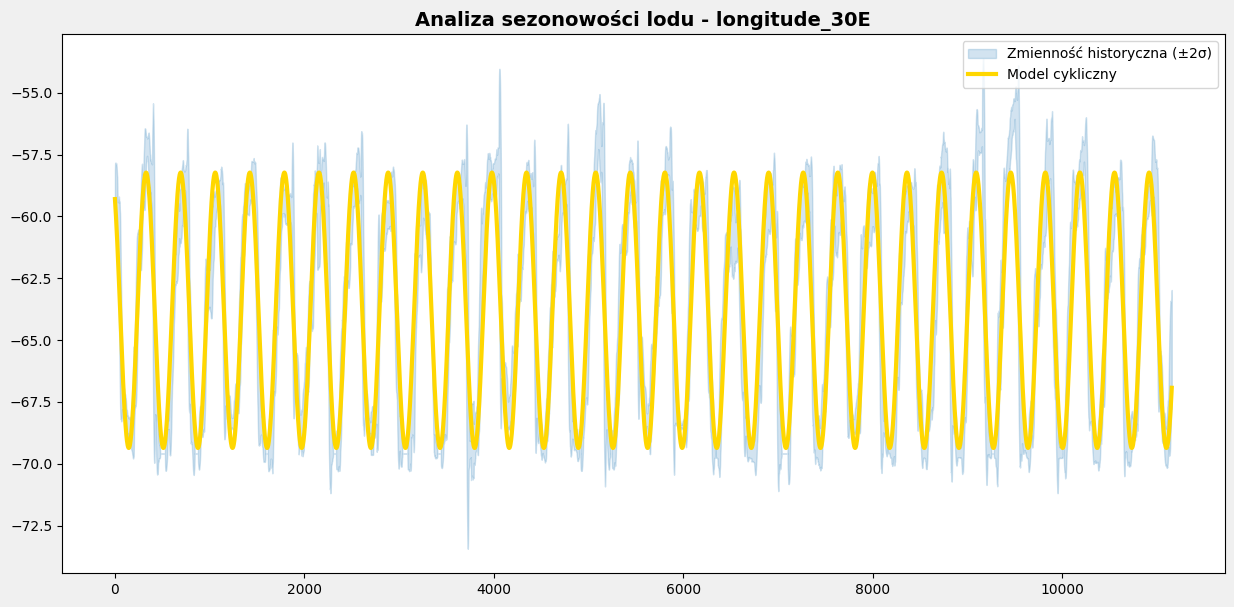

In [28]:
def sine_func(x, a, phi, d):
    # Częstotliwość f zamrożona na 1/365.25 dla stabilności długoterminowej
    return a * np.sin(2 * np.pi * (1/365.25) * x + phi) + d

sample_angle = 'longitude_30E'
subset = df_processed[df_processed['angle'] == sample_angle].sort_values('day_index')

if not subset.empty:
    popt, _ = curve_fit(sine_func, subset['day_index'], subset['latitude'], 
                        p0=[10, 0, subset['latitude'].mean()])
    
    # Obliczanie statystyk kroczących dla wygładzenia wizualizacji
    subset_rolled = subset.set_index(pd.to_datetime(subset['Date']))
    rolling = subset_rolled['latitude'].rolling(window='30D', center=True)
    subset['lat_mean'] = rolling.mean().values
    subset['lat_std'] = rolling.std().values

    # Wizualizacja trendu
    fig, ax = plt.subplots(figsize=(15, 7), facecolor='#f0f0f0')
    ax.set_facecolor('white')
    
    # Obszar zmienności (Ribbon plot)
    ax.fill_between(subset['day_index'], subset['lat_mean'] - 2*subset['lat_std'], 
                    subset['lat_mean'] + 2*subset['lat_std'], 
                    color='#1f77b4', alpha=0.2, label='Zmienność historyczna (±2σ)')
    
    # Model sinusoidalny (Kontrastowy żółty)
    x_fit = np.linspace(subset['day_index'].min(), subset['day_index'].max(), 5000)
    ax.plot(x_fit, sine_func(x_fit, *popt), color='#FFD700', linewidth=3, label='Model cykliczny', zorder=10)
    
    ax.set_title(f"Analiza sezonowości lodu - {sample_angle}", fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    plt.savefig(f"analiza_sezonowosci_{sample_angle}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [21]:
# 1. Przygotowanie zbiorów: X (cechy), y (cel)
# Test_size 0.2: wydzielenie 20% danych do walidacji krzyżowej
X = df_processed[['day_of_year', 'angle_num']]
y = df_processed['latitude']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# warm_start=True: umożliwia iteracyjne dodawanie drzew do lasu
rf_model = RandomForestRegressor(
    n_estimators=1,
    warm_start=True,
    random_state=42,
    n_jobs=-1
)

# 3. Pętla treningowa z monitoringiem postępu (tqdm)
# Przyrostowe budowanie ansamblu 100 drzew decyzyjnych
for i in tqdm(range(100), desc="Trenowanie drzew"):
    rf_model.n_estimators = i + 1
    rf_model.fit(X_train, y_train)

# 4. Ewaluacja metryką R^2 (Współczynnik determinacji)
# Określa dopasowanie modelu do wariancji danych testowych
score = rf_model.score(X_test, y_test)
print(f"R^2 Score: {score:.4f}")

Start trenowania Random Forest...


Trenowanie drzew:   1%|▋                                                               | 1/100 [00:05<09:22,  5.68s/it]


KeyboardInterrupt: 

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Wyznaczenie wartości przewidywanych dla zbioru testowego w celu weryfikacji zdolności generalizacyjnej.
y_pred = rf_model.predict(X_test)


# Współczynnik determinacji (R2) określa proporcję wariancji zmiennej zależnej wyjaśnianej przez model.
r2 = rf_model.score(X_test, y_test)

# Średni błąd bezwzględny (MAE) reprezentuje przeciętną wielkość błędów prognoz w jednostkach naturalnych.
mae = mean_absolute_error(y_test, y_pred)

# Pierwiastek błędu średniokwadratowego (RMSE) – miara wrażliwa na występowanie wartości odstających (outliers).
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print(f"Współczynnik R2: {r2:.4f}")
print(f"Błąd MAE: {mae:.2f}°")
print(f"Błąd RMSE: {rmse:.2f}°")


# Przyjmując stałą konwersję stopnia szerokości geograficznej na dystans (111.2 km/°).
error_km = mae * 111.2
print(f"Średni liniowy błąd prognozy: ok. {error_km:.2f} km")

--- Statystyki dopasowania modelu ---
Współczynnik R2: 0.8804
Błąd MAE: 1.00°
Błąd RMSE: 1.43°
Średni liniowy błąd prognozy: ok. 111.01 km


In [12]:
print("Predykcja...")

example_pred = pd.DataFrame({
    'day_of_year': [200],
    'angle_num': [30]
})

pred_val = rf_model.predict(example_pred)

print(f"Predykcja: {pred_val[0]:.3f}")

Predykcja...
Predykcja: -61.391


In [35]:
frames = []
days = list(range(1, 366, 5)) 
temp_dir = "frames_rf"
os.makedirs(temp_dir, exist_ok=True)


angles = sorted(df_processed['angle_num'].unique())


for i, day in enumerate(tqdm(days, desc="Renderowanie klatek")):
    


    current_day_data = pd.DataFrame({
        'day_of_year': [float(day)] * len(angles),
        'angle_num': angles
    })

 
    current_preds = rf_model.predict(current_day_data)

  
    df_frame = pd.DataFrame({
        'angle_num': angles,
        'latitude': current_preds
    }).sort_values('angle_num')
    
    # Konwersja na km i współrzędne XY
    df_frame['r'] = (90 + df_frame['latitude']) * 111.2
    df_frame['theta'] = np.radians(
        np.where(df_frame['angle_num'] < 0,
                 360 + df_frame['angle_num'] - 90,
                 df_frame['angle_num'] - 90)
    )

    df_frame['x'] = df_frame['r'] * np.cos(df_frame['theta'])
    df_frame['y'] = df_frame['r'] * np.sin(df_frame['theta'])

    # 4. RYSOWANIE (Tworzymy nową figurę od zera)
    fig, ax = plt.subplots(figsize=(8, 9)) 
    ax.set_facecolor('white')

  
    ax.plot(min_ice['x'], min_ice['y'], color='gray', linestyle='--', linewidth=1, label='Historyczne minimum')
    
    # Rysujemy dynamiczną linię lodu (to musi się ruszać!)
    ax.plot(df_frame['x'], df_frame['y'], color='#1f77b4', linewidth=2.5, label='Prognoza RF')
    
    ax.scatter(0, 0, color='red', s=50, label='Biegun Południowy')

    # Stałe osie - kluczowe dla animacji
    limit = 4500
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_aspect('equal') 
    ax.axis('off')


    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)
    ax.set_title(f"Model Predykcyjny: Dzień {day:03d}", fontsize=14, fontweight='bold')

 
    filename = f"{temp_dir}/frame_{i:03d}.png"
    plt.savefig(filename, dpi=100, bbox_inches='tight', pad_inches=0.5)
    plt.close(fig) # Bardzo ważne: zamykamy figurę

    frames.append(imageio.imread(filename))

# Zapis GIF
imageio.mimsave("rf_prediction_fixed.gif", frames, fps=10)
print("Gotowe. Sprawdź plik rf_prediction_fixed.gif")

Rozpoczynam renderowanie... Jeśli linia stoi w miejscu, sprawdzam dane wejściowe.


Renderowanie klatek: 100%|█████████████████████████████████████████████████████████████| 73/73 [00:16<00:00,  4.34it/s]


Gotowe. Sprawdź plik rf_prediction_fixed.gif
